# Delta Hedging Simulation

This notebook simulates a dynamic delta hedging strategy over the life of a European call option.

---

## 1. The Concept

A delta hedge eliminates directional exposure to the stock. If you sell a call with $\Delta = 0.50$, you buy 0.50 shares per option sold. If the stock rises by 1 dollar, your shares gain 0.50 dollars, exactly offsetting the loss on your short option position.

The problem is that $\Delta$ changes as the stock moves, that is known as Gamma.
So the hedge must be rebalanced periodically.

In theory, continuous rebalancing produces a perfect hedge with zero PnL. In practice, rebalancing happens at discrete intervals and small tracking errors accumulate. The distribution of those errors is what this notebook visualizes.

The full hedging PnL at expiration is:

$$\text{PnL} = \text{Cash account} + \Delta \cdot S_T - \max(S_T - K,\ 0)$$

where the last term is the option payoff owed to the buyer.

In [5]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from delta_hedge import delta_hedge_simulation
from black_scholes import black_scholes_call

## 2. Single Path Walkthrough

Before running many simulations, let's trace through a single path to understand the mechanics step by step.

Initial stock price: $150.00
Final stock price: $121.92
Option payoff owed: $0.00
Hedging PnL: $0.2320


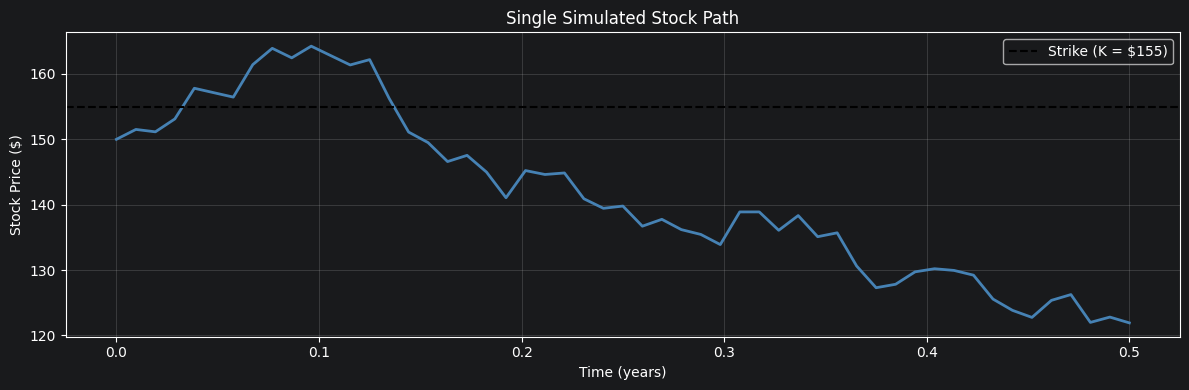

In [13]:
S0, K, T, r, sigma = 150, 155, 0.5, 0.05, 0.20

# run a single path
np.random.seed(42)
result = delta_hedge_simulation(S0, K, T, r, sigma, n_steps=52, n_sims=1)

path = result["paths"][0]
time = result["time"]
pnl  = result["pnls"][0]

print(f"Initial stock price: ${path[0]:.2f}")
print(f"Final stock price: ${path[-1]:.2f}")
print(f"Option payoff owed: ${max(path[-1] - K, 0):.2f}")
print(f"Hedging PnL: ${pnl:.4f}")

plt.figure(figsize=(12, 4))
plt.plot(time, path, color="steelblue", linewidth=2)
plt.axhline(y=K, color="black", linestyle="--", linewidth=1.5,
            label=f"Strike (K = ${K})")
plt.title("Single Simulated Stock Path", fontsize=12)
plt.xlabel("Time (years)")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. PnL Distribution Across Many Paths

Running 200 simulations shows that the hedging errors are centered near
zero, confirming the theoretical result that delta hedging replicates
the option payoff.

Mean PnL: $0.1132
Std PnL: $0.9848
Min PnL: $-2.9911
Max PnL: $2.9623


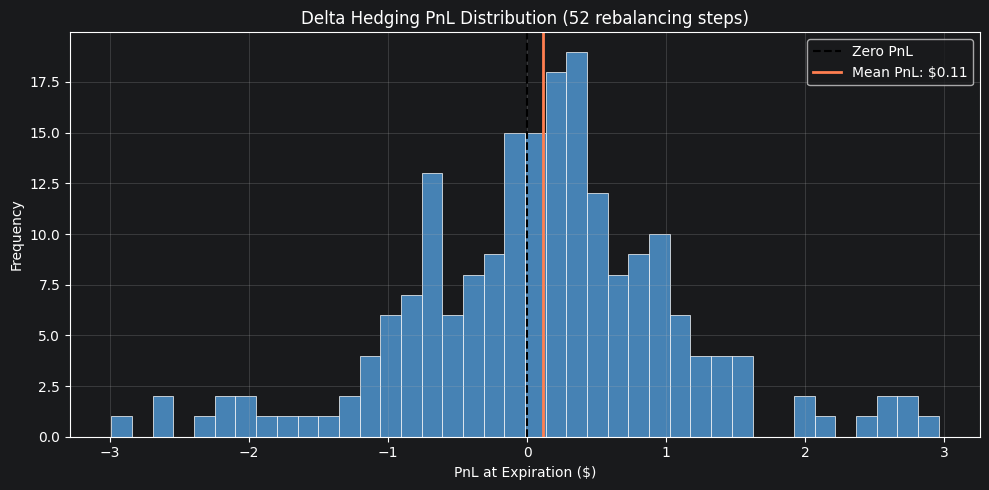

In [11]:
np.random.seed(0)
results = delta_hedge_simulation(S0, K, T, r, sigma, n_steps=52, n_sims=200)

pnls = results["pnls"]

print(f"Mean PnL: ${np.mean(pnls):.4f}")
print(f"Std PnL: ${np.std(pnls):.4f}")
print(f"Min PnL: ${np.min(pnls):.4f}")
print(f"Max PnL: ${np.max(pnls):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pnls, bins=40, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(x=0, color="black", linestyle="--", linewidth=1.5, label="Zero PnL")
ax.axvline(x=np.mean(pnls), color="coral", linestyle="-",
           linewidth=2, label=f"Mean PnL: ${np.mean(pnls):.2f}")
ax.set_title("Delta Hedging PnL Distribution (52 rebalancing steps)", fontsize=12)
ax.set_xlabel("PnL at Expiration ($)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/delta_hedge.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Effect of Rebalancing Frequency

The more frequently you rebalance, the smaller the tracking error.
This is the core result of Black-Scholes theory,  continuous rebalancing
produces a perfect hedge. We can verify this empirically.

4 steps - Std PnL: $3.0767
12 steps - Std PnL: $2.0354
52 steps - Std PnL: $0.9848
252 steps - Std PnL: $0.4529


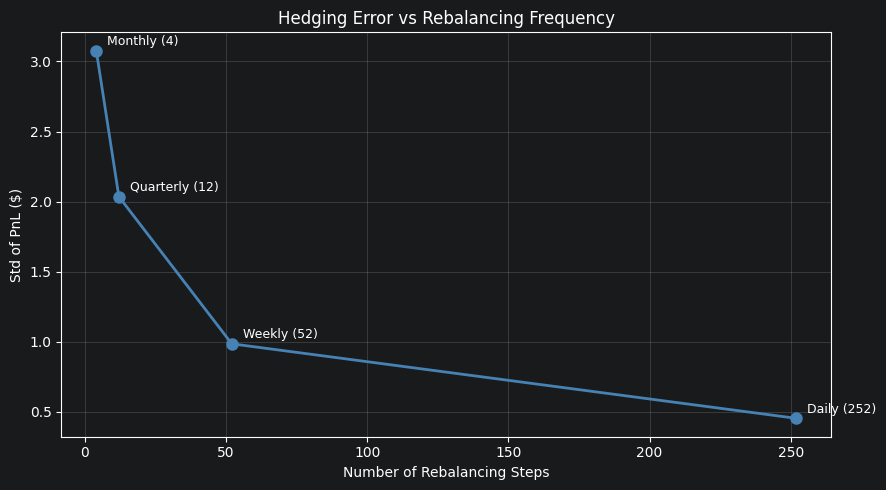

In [10]:
frequencies = [4, 12, 52, 252]
labels = ["Monthly (4)", "Quarterly (12)", "Weekly (52)", "Daily (252)"]
std_pnls = []

for n_steps in frequencies:
    np.random.seed(0)
    res = delta_hedge_simulation(S0, K, T, r, sigma, n_steps=n_steps, n_sims=200)
    std_pnls.append(np.std(res["pnls"]))
    print(f"{n_steps} steps - Std PnL: ${np.std(res['pnls']):.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(frequencies, std_pnls, "o-", color="steelblue", linewidth=2, markersize=8)
ax.set_title("Hedging Error vs Rebalancing Frequency", fontsize=12)
ax.set_xlabel("Number of Rebalancing Steps")
ax.set_ylabel("Std of PnL ($)")
ax.grid(alpha=0.3)
for i, label in enumerate(labels):
    ax.annotate(label, (frequencies[i], std_pnls[i]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
plt.tight_layout()
plt.savefig("../plots/hedge_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

- Delta hedging eliminates directional stock exposure by holding a dynamic
  share position equal to the option's Delta
- With weekly rebalancing, the mean hedging PnL is approximately zero,
  confirming the theoretical no-arbitrage result
- Hedging error decreases as rebalancing frequency increases, converging
  toward the perfect continuous hedge assumed by Black-Scholes
- Gamma determines how quickly Delta changes between rebalances, high Gamma
  means faster drift and larger potential tracking errors